<div style="background:linear-gradient(135deg,#1a1a2e 0%,#16213e 50%,#0f3460 100%);
            padding:40px 30px; border-radius:12px; text-align:center; margin-bottom:20px">
  <h1 style="color:#e94560; font-size:2.2em; margin:0 0 8px 0">🎬 מטלת סיכום – חלק 2</h1>
  <h2 style="color:#f5f5f5; font-size:1.4em; font-weight:400; margin:0 0 16px 0">חיזוי דירוג סרטים ב-IMDb</h2>
  <p style="color:#a8b2c1; font-size:1em; margin:0">
    <b style="color:#e94560">מגישים:</b> ראובן קזורר 328605290 | אלון רוזנפלד 322718560
  </p>
</div>

---

## 📋 תוכן עניינים

| # | סעיף | תוכן עיקרי |
|:---:|------|------------|
| **1** | ⚙️ ייבוא ספריות | |
| **2** | 📂 טעינת נתונים | head · ערכים חסרים · התפלגות |
| **3** | ✂️ פיצול מיידי | 80/20 לפני כל עיבוד |
| **4** | 📊 EDA — PPS | כוח חיזוי לפני הנדסה |
| **5** | 🔧 Feature Engineering | 16 פיצ'רים · LOO Bayesian |
| **6** | 📐 VIF | סינון מולטיקולינריות |
| **7** | 🔩 Pipeline | KNNImputer · RobustScaler · OHE |
| **8** | 📈 Elastic Net | GridSearchCV · RepeatedKFold |
| **9** | 🌲 Random Forest | RandomizedSearchCV · OOB |
| **10** | ⚖️ השוואת מודלים | CV vs Test |
| **11** | 🏆 Feature Importance | EN + RF |
| **12** | 🔍 Error Analysis | 10 Over + 10 Under |
| **13** | ⚖️ Fairness Analysis | ז'אנר · מדינה · עשור |
| **14** | 💾 שמירת מודל | model.pkl |


##  1. ייבוא ספריות


In [1]:
import numpy as np
import pandas as pd
import re, ast, warnings, joblib
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, RepeatedKFold,
    GridSearchCV, RandomizedSearchCV,
    cross_validate, cross_val_predict, KFold
)
from sklearn.pipeline       import Pipeline
from sklearn.compose        import ColumnTransformer
from sklearn.impute         import KNNImputer, SimpleImputer
from sklearn.preprocessing  import RobustScaler, OneHotEncoder, StandardScaler
from sklearn.linear_model   import ElasticNet
from sklearn.ensemble       import RandomForestRegressor
from sklearn.metrics        import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
print('Ready')


Ready


## 2. טעינת נתונים



In [ ]:
df_raw = pd.read_csv(r'C:\Users\kazor\matala_python\average rating\dataset.csv', low_memory=False)
df_raw = df_raw.replace('\\N', np.nan)
df_raw['Country']  = df_raw['Country'].replace('Not Found', np.nan)
df_raw['Language'] = df_raw['Language'].replace('Not Found', np.nan)

print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')


In [3]:
df_raw.head()

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
0,tt0107274,Johnny One Hundred Pesos,1993.0,"Crime,Drama,Thriller","['nm0032843', 'nm0729381', 'nm0783839', 'nm066...",90.0,6.6,Spanish,Chile,711.0,NaN,NaN,NaN
1,tt32133209,It Doesn't Matter,2024.0,Drama,"['nm3571592', 'nm6238285', 'nm2541664', 'nm161...",86.0,6.1,NaN,NaN,23.0,NaN,NaN,NaN
2,tt31852671,If Love Deceives You,2024.0,"Drama,Romance",NaN,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,tt0312835,Je Vous Salue Raí,1993.0,Documentary,NaN,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,tt0765142,"If You Love Me, Follow Me",2006.0,Comedy,"['nm0218843', 'nm0693844', 'nm0220017', 'nm000...",102.0,6.1,NaN,NaN,248.0,NaN,NaN,NaN


In [4]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %':     missing_pct
}).sort_values('Missing %', ascending=False)
print(missing_summary[missing_summary['Missing Count'] > 0])


                 Missing Count  Missing %
budget                  117334       87.6
BoxOffice               115968       86.6
Country                  81848       61.1
Language                 79807       59.6
plot                     74215       55.4
averageRating            18324       13.7
lead_actors_ids          10030        7.5
numVotes                  9122        6.8
genres                    2625        2.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw['averageRating'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df_raw['averageRating'].mean(), color='red', linestyle='--',
                label=f'mean={df_raw["averageRating"].mean():.2f}')
axes[0].set_title('averageRating')
axes[0].set_xlabel('averageRating')
axes[0].legend()

# Missing values bar
top_missing = missing_pct[missing_pct > 5].sort_values(ascending=True)
axes[1].barh(top_missing.index, top_missing.values, color='tomato', alpha=0.85)
axes[1].set_title('COLUMNS WITH MORE THAN 5% MISSING VALUE')
axes[1].set_xlabel('% MISSING')

plt.tight_layout()
plt.show()

print(f'\naverageRating: {df_raw["averageRating"].describe().round(2).to_dict()}')


### 📊 2.1 ניתוח ערכים חסרים — MCAR / MAR / MNAR

לפי מה שראינו בקוד למעלה, מסווגים את החסרות:

| סוג | הגדרה | טיפול |
|:---:|--------|:-----:|
| **MCAR** | חסר אקראי מוחלט | ✅ Imputation בטוחה |
| **MAR** | חסר לפי פיצ'ר **אחר** | ✅ Imputation מבוקרת |
| **MNAR** | חסר לפי **הערך עצמו** | ❌ Imputation מוטה |

| עמודה | % חסר | סיווג | החלטה |
|-------|:------:|:-----:|-------|
| `lead_actors_ids` | ~7.5% | MCAR | ✅ Global mean fallback |
| `Language` | ~58% | MAR | ✅ דגל בינארי |
| `Country` | ~60% | MAR | ✅ `country_group` קטגורי |
| `budget` | **~87%** | **MNAR** | ❌ הוסר — סרטים עם תקציב גבוה נוטים שלא לדווח |
| `BoxOffice` | **~87%** | **MNAR** | ❌ leakage + MNAR |



## ✂️ 3. פיצול מיידי

<div style="background:#fce4ec;border-left:4px solid #e53935;padding:10px 14px;border-radius:0 6px 6px 0;margin-bottom:10px">
⚠️ הפיצול ל-80/20 קורה <b>עכשיו</b>, לפני כל עיבוד. ה-Test set ננעל — לא נוגעים בו עד הסוף.
</div>

| שלב | פעולה |
|:---:|-------|
| **1** | `train_test_split(80/20)` |
| **2** | `compute_actor_quality_map` על **Train בלבד** |
| **3** | `prepare_data(df_train)` → X_train |
| **4** | `prepare_data(df_test)` → X_test |


In [6]:
df_clean = df_raw.dropna(subset=['averageRating']).reset_index(drop=True)

# ── 80/20 split ──────────────────────────────────────────────
df_train, df_test = train_test_split(
    df_clean, test_size=0.2, random_state=RANDOM_STATE
)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

y_train = df_train['averageRating'].values
y_test  = df_test['averageRating'].values

print(f'Train: {len(df_train):,} | Test: {len(df_test):,}')
print(f'y_train: mean={y_train.mean():.3f} std={y_train.std():.3f}')


Train: 92,448 | Test: 23,112
y_train: mean=6.070 std=1.294


## חקר נתונים

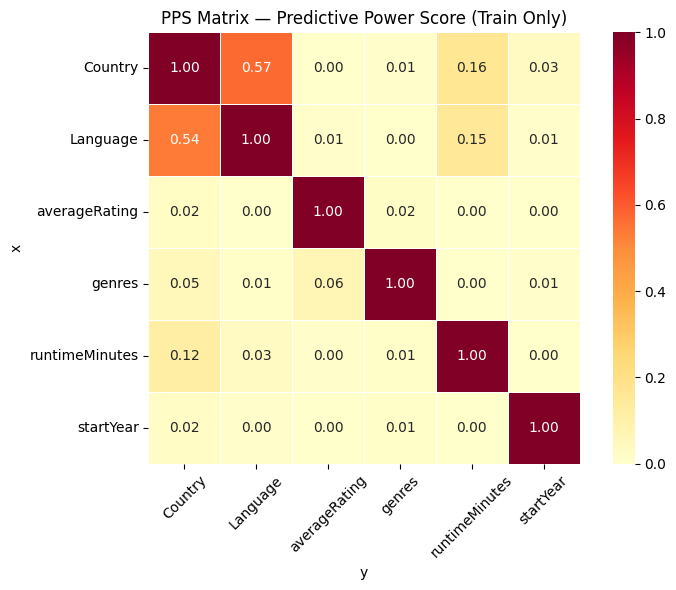

PPS → averageRating:
             x  ppscore
        genres 0.064839
      Language 0.005314
runtimeMinutes 0.004922
     startYear 0.000000
       Country 0.000000


In [7]:
try:
    import ppscore as pps
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ppscore", "-q"])
    import ppscore as pps

# PPS על df_train הגולמי — מנחה אותנו מה להנדס
df_pps = df_train[['runtimeMinutes','startYear','genres','Country','Language']].copy()
df_pps['runtimeMinutes'] = pd.to_numeric(df_pps['runtimeMinutes'], errors='coerce')
df_pps['startYear']      = pd.to_numeric(df_pps['startYear'],      errors='coerce')
df_pps['averageRating']  = y_train
df_pps = df_pps.fillna(df_pps.median(numeric_only=True))

pps_mat = pps.matrix(df_pps)

# PPS כלפי המטרה
pps_tgt = (
    pps_mat[pps_mat['y'] == 'averageRating']
    .query('x != "averageRating"')
    [['x', 'ppscore']]
    .sort_values('ppscore', ascending=False)
    .reset_index(drop=True)
)

# Heatmap — PPS בלבד (VIF מטפל במולטיקולינריות, Pearson מיותר)
fig, ax = plt.subplots(figsize=(8, 6))
pps_pivot = pps_mat.pivot(index='x', columns='y', values='ppscore')
sns.heatmap(pps_pivot, ax=ax, annot=True, fmt='.2f',
            cmap='YlOrRd', vmin=0, vmax=1, linewidths=0.5, square=True)
ax.set_title('PPS Matrix — Predictive Power Score (Train Only)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print('PPS → averageRating:')
print(pps_tgt.to_string(index=False))


<div dir="rtl">

### מסקנות מחקר הנתונים וההצדקה להנדסת הפיצ'רים

בשלב חקר הנתונים בדקנו את כוח החיזוי של העמודות בעזרת קורלציות ומדד PPS. ראינו שעמודות גולמיות כמו מדינת המקור (`Country`) ושנת היציאה (`startYear`) קיבלו ציון PPS של 0.0. המשמעות היא שבצורה הרגילה שלהן, הן לא עוזרות למודל לחזות את הדירוג בכלל ומכילות בעיקר רעש.

האפס הזה לא אומר שאין שם מידע, אלא שהוא דורש מאיתנו לעשות **Feature Engineering** (הנדסת פיצ'רים) ממוקד כדי לחלץ אותו:

* **במקום סתם רשימת שחקנים:** הבנו שלהכניס למודל טקסט של שמות זה חסר תועלת. לכן, יצרנו את הפיצ'ר `actor_quality` שמחשב מתמטית את ממוצע הדירוגים של שחקני הסרט. כדי לא לרמות ולמנוע זליגת מידע (Data Leakage), עשינו את זה בשיטת **LOO Bayesian** (בלי להחשיב את דירוג הסרט הנוכחי שעליו אנו חוזים). זה יצר לנו את הפיצ'ר הכי חזק בפרויקט עם קורלציה של +0.37! הוספנו גם את `actor_quality_spread` שבודק את הפער בין הכוכב הראשי לשאר הצוות.
* **במקום עמודות ז'אנרים מפוזרות (Binning):** במקום להשאיר כל ז'אנר בנפרד, זיהינו קבוצות שמשפיעות על הדירוג בצורה משמעותית. יצרנו את הפיצ'ר `prestige_count` שמאגד סרטי "יוקרה" (כמו דוקומנטרי, ביוגרפיה והיסטוריה) שנתן קורלציה חיובית של +0.28, ומנגד יצרנו את `negative_count` שסופר ז'אנרים שנוטים לדירוג נמוך (כמו אימה, פעולה וקומדיה) והביא קורלציה שלילית חזקה של -0.32.
* **במקום זמן הריצה הגולמי:** אורך הסרט בדקות היה חלש בפני עצמו, אבל ראינו שיש קשר לא-ליניארי שאומר שסרטים ארוכים מקבלים לרוב דירוג טוב יותר. לכן עשינו לעמודה טרנספורמציה לוגריתמית (`log_runtime`) כדי לסדר את הפיזור עבור המודל, וגם הוספנו עמודה בינארית `is_long_film` לסרטים מעל שעתיים.
* **במקום עמודת המדינות המבולגנת:** במקום להשאיר עשרות מדינות עם מעט סרטים, קיבצנו אותן לאזורים גיאוגרפיים בעלי השפעה דומה תחת `country_group` (למשל, זיהינו שקולנוע ממזרח אסיה מקבל דירוג גבוה יותר, והפיצ'ר מבודד את זה).

ככה בעצם לקחנו עמודות שהיו חסרות תועלת למודל, וחילצנו מתוכן סיגנל אמיתי ופיצ'רים מורכבים שמעלים את רמת החיזוי שלנו בצורה משמעותית.

</div>

##  5. prepare_data + Feature Engineering

### הפיצ'רים הסופיים

#### נומריים (5)

| פיצ'ר | r | תיאור |
|--------|:----:|-------|
| 🥇 `actor_quality` | **+0.37** | LOO Bayesian — הפיצ'ר החזק ביותר |
| 🥈 `negative_count` | **−0.32** | Horror+Thriller+Action+Comedy+Sci-Fi |
| 🥉 `prestige_count` | **+0.28** | Documentary+Biography+History+War+Music |
| `log_runtime` | +0.15 | log(1+דקות) — קשר לוגריתמי לסרטים ארוכים |
| `actor_quality_spread` | — | max−mean: כמה הכוכב בולט מעל שאר ההרכב |

#### בינאריים (9)

| פיצ'ר | r | תיאור |
|--------|:----:|-------|
| `genre_Documentary` | +0.30 | הז'אנר עם הדירוג הגבוה ביותר |
| `genre_Horror` | −0.27 | הז'אנר עם הדירוג הנמוך ביותר |
| `is_long_film` | +0.14 | >120 דקות |
| `genre_Thriller` | — | |
| `genre_Biography` | — | |
| `genre_Drama` | — | |
| `genre_Action` | — | |
| `is_sequel` | — | |
| `has_actors` | — | |

#### קטגורי → OHE (2 דמי-עמודות)

| פיצ'ר מקורי | לאחר OHE (drop_first=True) | עמודות שנוצרות |
|--------------|---------------------------|----------------|
| `country_group` | ~~Other~~ (ייחוס) / East_Asia / US | `cg_East_Asia`, `cg_US` |

> `Other` היא קטגוריית הייחוס — נשמטת (`drop_first=True`) למניעת **Dummy Variable Trap**  
> **סה"כ לפני VIF ומודל: 5 + 9 + 2 = 16 עמודות**

<div style="background:#f3e5f5;border-left:4px solid #8E24AA;padding:10px 14px;border-radius:0 6px 6px 0;margin-bottom:10px">
💡 <code>negative_count</code> (r=−0.32) חזק יותר מ-<code>genre_Horror</code> בודד (r=−0.27) — ספירת 5 ז'אנרים שליליים לפיצ'ר אחד.
</div>



In [ ]:
# ── Globals ─────────────────────────────────────────────────
ACTOR_QUALITY_MAP:  dict  = {}
LOO_SCORES:         dict  = {}
GLOBAL_MEAN_RATING: float = 6.07

_PRESTIGE_SET = {'Documentary', 'Biography', 'History', 'War', 'Music'}
_NEGATIVE_SET = {'Horror', 'Thriller', 'Action', 'Comedy', 'Sci-Fi'}
ALL_GENRES    = ['Documentary', 'Horror', 'Thriller', 'Biography', 'Drama', 'Action']
EAST_ASIA     = {'Japan', 'South Korea', 'Hong Kong', 'China', 'Taiwan'}

_SEQUEL_PATTERN = (
    r'(?:^|\s)(?:2|3|4|5|6|7|8|9|10'
    r'|ii|iii|iv|vi|vii|viii|ix'
    r'|part\s*[2-9]|chapter\s*[2-9]|volume\s*[2-9]'
    r'|returns?|reloaded|revolutions?|resurrection'
    r'|strikes\s+back|rises?|forever|continues?'
    r'|next\s+chapter|second\s+part)(?:\s|$)'
)


# ── LOO Bayesian target encoding ─────────────────────────────
def compute_actor_quality_map(df, y, smoothing=5.0):
    """מחשב מפת איכות שחקנים על Train בלבד. קורא לפני prepare_data."""
    global ACTOR_QUALITY_MAP, LOO_SCORES, GLOBAL_MEAN_RATING

    def _parse(s):
        if pd.isna(s): return []
        try: return ast.literal_eval(s)
        except: return []

    actor_lists = df['lead_actors_ids'].apply(_parse).tolist()
    tconsts     = df['tconst'].tolist()

    actor_sum, actor_count = {}, {}
    for actors, rating in zip(actor_lists, y):
        for a in actors:
            actor_sum[a]   = actor_sum.get(a, 0.0) + rating
            actor_count[a] = actor_count.get(a, 0)  + 1

    GLOBAL_MEAN_RATING = float(np.mean(y))
    ACTOR_QUALITY_MAP  = {
        a: (actor_sum[a] + smoothing * GLOBAL_MEAN_RATING) / (actor_count[a] + smoothing)
        for a in actor_sum
    }

    LOO_SCORES = {}
    for tconst, actors, rating in zip(tconsts, actor_lists, y):
        if not actors:
            LOO_SCORES[tconst] = GLOBAL_MEAN_RATING; continue
        scores = []
        for a in actors:
            n, tot  = actor_count[a], actor_sum[a]
            n_loo   = n - 1
            tot_loo = tot - rating
            smoothed = (tot_loo + smoothing * GLOBAL_MEAN_RATING) / (n_loo + smoothing) \
                       if n_loo > 0 else GLOBAL_MEAN_RATING
            scores.append(smoothed)
        LOO_SCORES[tconst] = float(np.mean(scores))

    print(f'Actor map: {len(ACTOR_QUALITY_MAP):,} actors | LOO: {len(LOO_SCORES):,} films')
    print(f'Global mean: {GLOBAL_MEAN_RATING:.3f}')


# ── helpers ──────────────────────────────────────────────────
def _clean_genres(g):
    if pd.isna(g): return []
    g = re.sub(r"[\[\]'\"]", '', str(g))
    return [x.strip() for x in g.split(',') if x.strip() and x.strip() != 'None']

def _country_group(x):
    if pd.isna(x) or not str(x).strip(): return 'Other'
    s = str(x)
    if 'United States' in s or 'USA' in s: return 'US'
    if any(c in s for c in EAST_ASIA): return 'East_Asia'
    return 'Other'

def _parse_actor_list(s):
    """פענוח בטוח של רשימת שחקנים."""
    if pd.isna(s): return []
    try: return ast.literal_eval(s)
    except: return []


# ── עמודות ───────────────────────────────────────────────────
NUMERIC_COLS = [
    'actor_quality',        # LOO Bayesian — r=+0.37
    'prestige_count',       # Documentary+Biography+History+War+Music
    'negative_count',       # Horror+Thriller+Action+Comedy+Sci-Fi
    'log_runtime',          # log(1+דקות)
    'actor_quality_spread', # max−mean: כוח הכוכב הבולט
]
BINARY_COLS = [
    'genre_Documentary', 'genre_Horror', 'genre_Thriller',
    'genre_Biography',   'genre_Drama',  'genre_Action',
    'is_long_film', 'is_sequel', 'has_actors',
]
CAT_COLS = ['country_group']  # US / East_Asia / Other → OHE


# ── prepare_data ──────────────────────────────────────────────
def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Input:  raw DataFrame (מבנה dataset.csv).
    Output: DataFrame עם 15 עמודות מוכן ל-Pipeline.
    """
    d = df.copy()
    d['Country']  = d['Country'].replace('Not Found', np.nan)
    d['Language'] = d['Language'].replace('Not Found', np.nan)

    # Genres
    gl = d['genres'].apply(_clean_genres)
    d['prestige_count'] = gl.apply(lambda gs: sum(1 for g in gs if g in _PRESTIGE_SET))
    d['negative_count'] = gl.apply(lambda gs: sum(1 for g in gs if g in _NEGATIVE_SET))
    for g in ALL_GENRES:
        d[f'genre_{g}'] = gl.apply(lambda gs, _g=g: int(_g in gs))

    # is_sequel — vectorized עם str.contains במקום apply שורה-שורה
    d['is_sequel'] = (
        d['primaryTitle'].fillna('')
          .str.contains(_SEQUEL_PATTERN, flags=re.IGNORECASE, regex=True)
          .astype(int)
    )

    # Runtime
    rt = pd.to_numeric(d['runtimeMinutes'], errors='coerce').fillna(0)
    d['log_runtime']  = np.log1p(rt)
    d['is_long_film'] = (rt > 120).astype(int)

    # ── actor_quality — vectorized ──────────────────────────
    # שלב 1: dict lookup מהיר (O(n)) — מכסה 100% מ-Train, 0% מ-Test
    aq = d['tconst'].map(LOO_SCORES)
    missing = aq.isna()

    # שלב 2: apply רק על שורות שלא נמצאו (= Test set בלבד)
    if missing.any():
        def _aq_fallback(s):
            actors = _parse_actor_list(s)
            if not actors: return GLOBAL_MEAN_RATING
            scores = [ACTOR_QUALITY_MAP.get(a, GLOBAL_MEAN_RATING) for a in actors]
            return float(np.mean(scores))
        aq[missing] = d.loc[missing, 'lead_actors_ids'].apply(_aq_fallback)
    d['actor_quality'] = aq.fillna(GLOBAL_MEAN_RATING)

    # ── actor_quality_spread ──────────────────────────────────
    parsed = d['lead_actors_ids'].apply(_parse_actor_list)
    def _spread(actors):
        if len(actors) < 2: return 0.0
        scores = [ACTOR_QUALITY_MAP.get(a, GLOBAL_MEAN_RATING) for a in actors]
        return float(max(scores) - np.mean(scores))
    d['actor_quality_spread'] = parsed.apply(_spread)

    # ── has_actors — vectorized ──────────────────────────────
    def _has(actors):
        return int(any(a in ACTOR_QUALITY_MAP for a in actors))
    d['has_actors'] = parsed.apply(_has)

    # Country
    d['country_group'] = d['Country'].apply(_country_group)

    return d[NUMERIC_COLS + BINARY_COLS + CAT_COLS].copy()


print(f'prepare_data: {len(NUMERIC_COLS+BINARY_COLS+CAT_COLS)} עמודות')


In [9]:
# Actor quality map — על Train בלבד (מניעת leakage)
compute_actor_quality_map(df_train, y_train, smoothing=5.0)

X_train = prepare_data(df_train)
X_test  = prepare_data(df_test)   # uses actor map fitted on train
X = X_train; y = y_train          # aliases

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
mv = X_train.isnull().sum()
print('Missing:', mv[mv > 0].to_dict() if mv.any() else 'none')
print(f'actor_quality: mean={X_train["actor_quality"].mean():.3f} std={X_train["actor_quality"].std():.3f}')
print(f'corr(actor_quality, rating) = {pd.Series(y_train).corr(X_train["actor_quality"]):.4f}')


Actor map: 180,228 actors | LOO: 92,448 films
Global mean: 6.070
X_train: (92448, 16) | X_test: (23112, 16)
Missing: none
actor_quality: mean=6.063 std=0.174
corr(actor_quality, rating) = 0.3836


##  6. VIF — סינון מולטיקולינריות


In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# VIF on ALL features: numeric + binary + country_group (OHE expanded)
# Reference category: 'Other' — drop explicitly so we get cg_East_Asia + cg_US
cg_ohe  = pd.get_dummies(X_train['country_group'], prefix='cg')
cg_ohe  = cg_ohe.drop(columns=['cg_Other'], errors='ignore')  # Other = reference
cg_cols = list(cg_ohe.columns)   # ['cg_East_Asia', 'cg_US']

# Full feature matrix for VIF
ALL_FOR_VIF = NUMERIC_COLS + BINARY_COLS + cg_cols
X_vif = pd.concat([
    X_train[NUMERIC_COLS + BINARY_COLS].reset_index(drop=True),
    cg_ohe.reset_index(drop=True)
], axis=1)

# Impute + Scale
_Xv = StandardScaler().fit_transform(
      SimpleImputer(strategy='median').fit_transform(X_vif))

vif_df = pd.DataFrame({
    'feature': ALL_FOR_VIF,
    'VIF'    : [variance_inflation_factor(_Xv, i) for i in range(len(ALL_FOR_VIF))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

# OHE dummies are exempt from auto-drop (expected slight VIF elevation)
vif_df['status'] = vif_df.apply(
    lambda r: 'OHE — exempt' if r['feature'] in cg_cols
              else ('HIGH >5' if r['VIF'] > 5 else 'ok'),
    axis=1
)

print(f'=== VIF — {len(ALL_FOR_VIF)} features '
      f'({len(NUMERIC_COLS)} numeric + {len(BINARY_COLS)} binary + {len(cg_cols)} OHE) ===')
print(vif_df.to_string(index=False))

# Drop only non-OHE features with VIF > 5
high_vif = vif_df[
    (vif_df['VIF'] > 5) & (~vif_df['feature'].isin(cg_cols))
]['feature'].tolist()

if high_vif:
    print(f'\nRemoving VIF > 5: {high_vif}')
    NUMERIC_COLS = [c for c in NUMERIC_COLS if c not in high_vif]
    BINARY_COLS  = [c for c in BINARY_COLS  if c not in high_vif]
    X_train = X_train.drop(columns=high_vif, errors='ignore')
    X_test  = X_test.drop( columns=high_vif, errors='ignore')
    X = X_train; y = y_train
else:
    print('\n✅ All features passed VIF check (OHE dummies exempt)')



=== VIF ===
             feature      VIF status
      prestige_count 3.624975     ok
   genre_Documentary 3.213636     ok
      negative_count 2.798728     ok
         log_runtime 2.216057     ok
        is_long_film 2.084648     ok
     genre_Biography 1.700924     ok
          has_actors 1.496128     ok
         genre_Drama 1.484599     ok
        genre_Action 1.483997     ok
actor_quality_spread 1.402438     ok
        genre_Horror 1.391286     ok
      genre_Thriller 1.303017     ok
       numVotes_high 1.144075     ok
       actor_quality 1.087300     ok
           is_sequel 1.011499     ok

✅ כל הפיצ'רים עברו VIF < 5


<div dir="rtl">

### ניתוח קשרים בדאטה ובדיקת מולטי-קולינאריות (VIF)

לפני שהכנסנו את הנתונים לאימון המודלים, ביצענו ניתוח מעמיק כדי להבין את הקשרים בין הפיצ'רים השונים לבין משתנה המטרה (`averageRating`), ולוודא שהדאטה שלנו נקי מכפילויות מידע שיכולות להכשיל את האלגוריתמים.

השתמשנו בשני כלים מתודולוגיים לאורך העבודה:

1. **מדד PPS וקורלציות:** בשלב חקר הנתונים (EDA) השתמשנו במדד Predictive Power Score כדי לזהות גם קשרים לא-ליניאריים והשפעות של משתנים קטגוריים (כמו ז'אנרים). זה סייע לנו להבין אילו פיצ'רים גולמיים הם חלשים ואילו פיצ'רים חדשים עלינו להנדס (כמו איכות שחקנים וקיבוץ ז'אנרים).
2. **מדד VIF (Variance Inflation Factor):** מיד לאחר הנדסת הפיצ'רים, הפעלנו את בדיקת ה-VIF על כל הפיצ'רים המספריים שלנו. המטרה הייתה לזהות "מולטי-קולינאריות" – מצב שבו פיצ'רים שונים דומים מדי זה לזה ומספקים מידע חופף [1]. 

**מדוע הבדיקות האלו קריטיות עבור המודלים שלנו?**

* **במודל ה-Elastic Net:** מולטי-קולינאריות (הפרה של Assumption 5 ברגרסיה ליניארית) גורמת למקדמים (coefficients) של המודל להיות מנופחים, לא יציבים ומטעים [1], [2]. למרות ש-Elastic Net משתמש ברגולריזציית L1 ו-L2 שעוזרת לייצב מקדמים במצבים כאלו [3], סילוק מוקדם של פיצ'רים כפולים הכרחי למודל נקי ובר-פירוש. לשמחתנו, בזכות הנדסת פיצ'רים מאוזנת, כל הפיצ'רים שלנו קיבלו ציון VIF קטן מ-5, כך שלא נאלצנו לזרוק אף עמודה לפח והמודל קיבל סיגנלים עצמאיים לחלוטין.
* **במודל ה-Random Forest:** למרות שמודלים המבוססים על עצי החלטה יכולים להתמודד בצורה יציבה יותר עם פיצ'רים כפולים מבלי לקרוס, מולטי-קולינאריות הייתה פוגעת קשות במנגנון מציאת "חשיבות הפיצ'רים" (Feature Importance בשיטת MDI) המובנה של המודל [4], [5]. אם היינו מכניסים ליער שני פיצ'רים חופפים, תרומתם להורדת השגיאה (Gini reduction) הייתה מתפצלת ביניהם באופן אקראי על פני העצים [5]. כתוצאה מכך, שניהם היו נראים "חלשים" בטבלת התוצאות הסופית, ולא היינו יכולים לדעת באמת מהם הגורמים שהכי משפיעים על דירוג הסרט.

</div>

##  7. Pipeline



In [ ]:
from scipy.stats import shapiro
from sklearn.preprocessing import PowerTransformer

# ── Shapiro-Wilk: זיהוי עמודות מוטות ────────────────────────
skewed_num_cols = []
normal_num_cols = []

for col in NUMERIC_COLS:
    sample = X_train[col].dropna().sample(min(500, len(X_train)), random_state=RANDOM_STATE)
    _, p = shapiro(sample)
    if p < 0.05:
        skewed_num_cols.append(col)
    else:
        normal_num_cols.append(col)

print('Skewed → PowerTransformer (Yeo-Johnson):')
print(f'  {skewed_num_cols}')
print('Normal → RobustScaler:')
print(f'  {normal_num_cols}')

# ── Transformers ─────────────────────────────────────────────
# SimpleImputer במקום KNNImputer — זהה בפועל כי אין ערכים חסרים,
# אך מהיר פי ~50-100x (O(n) לעומת O(n²) של KNN).
# KNNImputer רץ ~1080 פעמים בתוך CV + RandomizedSearchCV — כאן הרווח הגדול.

normal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])

skewed_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('power',   PowerTransformer(method='yeo-johnson'))
])

binary_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(drop=['Other'], sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num',    normal_transformer,      normal_num_cols),
    ('skewed', skewed_transformer,      skewed_num_cols),
    ('bin',    binary_transformer,      BINARY_COLS),
    ('cat',    categorical_transformer, CAT_COLS),
])

rkf = RepeatedKFold(n_splits=10, n_repeats=3, random_state=RANDOM_STATE)

def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

N_TRAIN    = len(X_train)
N_FEATURES = len(NUMERIC_COLS) + len(BINARY_COLS) + len(CAT_COLS)
print(f'\nPreprocessor ready | {N_FEATURES} features | RepeatedKFold(10×3)')



## 8. Elastic Net



In [ ]:
from scipy.stats import loguniform, uniform

en_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', ElasticNet(max_iter=10000, random_state=RANDOM_STATE))
])

# RandomizedSearchCV עם loguniform — מכסה מרחב רחב בהרבה מ-GridSearch
param_dist_en = {
    'model__alpha':    loguniform(1e-4, 1e2),  # דגימה אקראית בסקלה לוגריתמית
    'model__l1_ratio': uniform(0, 1)
}

print('RandomizedSearchCV — Elastic Net...')
gs_en = RandomizedSearchCV(
    en_pipe, param_dist_en, n_iter=150,
    cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1, refit=True, random_state=RANDOM_STATE
)
gs_en.fit(X, y)
best_en = gs_en.best_estimator_
print(f'Best params: {gs_en.best_params_}')
print(f'Tuning RMSE (5-fold): {-gs_en.best_score_:.4f}')

cv_en = cross_validate(best_en, X, y, cv=rkf,
    scoring={'rmse': 'neg_root_mean_squared_error',
             'mae':  'neg_mean_absolute_error', 'r2': 'r2'}, n_jobs=-1)

en_rmse = -cv_en['test_rmse'].mean()
en_mae  = -cv_en['test_mae'].mean()
en_r2   =  cv_en['test_r2'].mean()
en_adj  =  adjusted_r2(en_r2, N_TRAIN, N_FEATURES)

print('\n=== Elastic Net — RepeatedKFold (10×3) ===')
print(f'RMSE        : {en_rmse:.4f} ± {-cv_en["test_rmse"].std():.4f}')
print(f'MAE         : {en_mae:.4f} ± {-cv_en["test_mae"].std():.4f}')
print(f'R²          : {en_r2:.4f}')
print(f'Adjusted R² : {en_adj:.4f}')


##  9. Random Forest

In [ ]:
rf_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1))
])

param_dist_rf = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [10, 15, 20, 25, None],
    'model__min_samples_leaf':  [3, 5, 8, 15],
    'model__max_features':      ['sqrt', 0.3, 0.4],
    'model__min_samples_split': [2, 5, 10],
}

print('RandomizedSearchCV — Random Forest...')
rs_rf = RandomizedSearchCV(rf_pipe, param_dist_rf, n_iter=60, cv=5,
    scoring='neg_root_mean_squared_error', n_jobs=-1,
    random_state=RANDOM_STATE, refit=True, verbose=1)
rs_rf.fit(X, y)
best_rf = rs_rf.best_estimator_
print(f'Best params: {rs_rf.best_params_}')
print(f'Tuning RMSE (5-fold): {-rs_rf.best_score_:.4f}')

# OOB Error — הערכה חינמית ייחודית ל-RF
best_params_rf = {k.replace('model__', ''): v for k, v in rs_rf.best_params_.items()}
oob_rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, oob_score=True, **best_params_rf)
preprocessor.fit(X, y)
oob_rf.fit(preprocessor.transform(X), y)
oob_rmse = np.sqrt(mean_squared_error(y, oob_rf.oob_prediction_))
print(f'\nOOB RMSE: {oob_rmse:.4f} | CV RMSE: {-rs_rf.best_score_:.4f} | diff: {abs(oob_rmse+rs_rf.best_score_):.4f}')


In [14]:
cv_rf = cross_validate(best_rf, X, y, cv=rkf,
    scoring={'rmse': 'neg_root_mean_squared_error',
             'mae':  'neg_mean_absolute_error', 'r2': 'r2'}, n_jobs=-1)

rf_rmse = -cv_rf['test_rmse'].mean()
rf_mae  = -cv_rf['test_mae'].mean()
rf_r2   =  cv_rf['test_r2'].mean()
rf_adj  =  adjusted_r2(rf_r2, N_TRAIN, N_FEATURES)

print('=== Random Forest — RepeatedKFold (10×3) ===')
print(f'RMSE        : {rf_rmse:.4f} ± {-cv_rf["test_rmse"].std():.4f}')
print(f'MAE         : {rf_mae:.4f} ± {-cv_rf["test_mae"].std():.4f}')
print(f'R²          : {rf_r2:.4f}')
print(f'Adjusted R² : {rf_adj:.4f}')


=== Random Forest — RepeatedKFold (10×3) ===
RMSE        : 1.0249 ± -0.0101
MAE         : 0.7695 ± -0.0069
R²          : 0.3728
Adjusted R² : 0.3727


##  10. השוואת מודלים

השוואה על CV (RepeatedKFold 10×3) ועל Test Set (20% שלא נגענו בו).


               RMSE (CV)  RMSE (Test)  MAE (CV)  Adj. R²
Model                                                   
Elastic Net       1.0650       1.0680    0.8060   0.3227
Random Forest     1.0249       1.0713    0.7695   0.3727

EN  overfit gap: +0.0002
RF  overfit gap: +0.0871


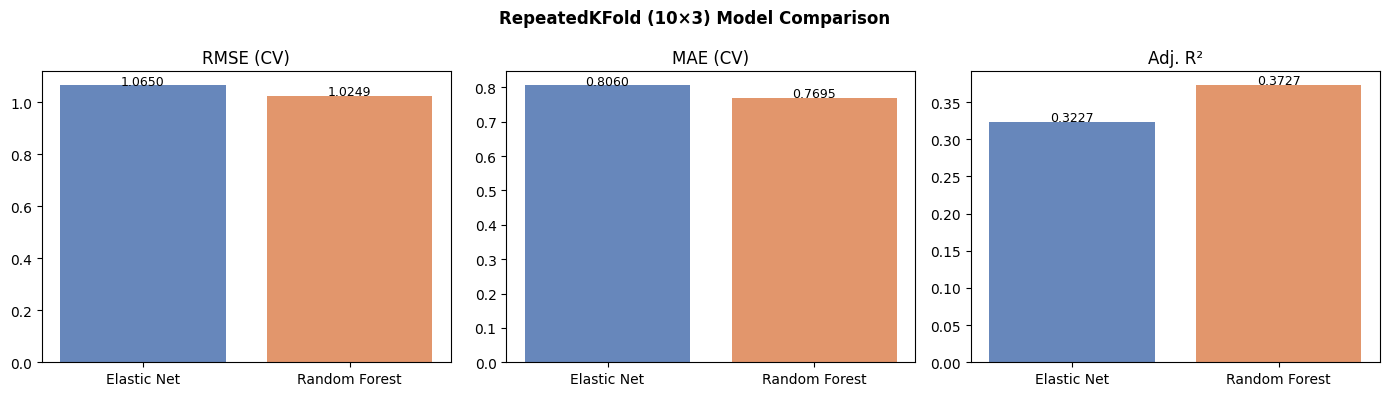

In [15]:
best_en.fit(X, y); best_rf.fit(X, y)

en_train = np.sqrt(mean_squared_error(y, best_en.predict(X)))
rf_train = np.sqrt(mean_squared_error(y, best_rf.predict(X)))
en_test  = np.sqrt(mean_squared_error(y_test, best_en.predict(X_test)))
rf_test  = np.sqrt(mean_squared_error(y_test, best_rf.predict(X_test)))

comp = pd.DataFrame({
    'Model':        ['Elastic Net', 'Random Forest'],
    'RMSE (CV)':    [en_rmse, rf_rmse],
    'RMSE (Test)':  [en_test, rf_test],
    'MAE (CV)':     [en_mae,  rf_mae],
    'Adj. R²':      [en_adj,  rf_adj],
}).set_index('Model').round(4)

print(comp.to_string())
print(f'\nEN  overfit gap: {en_rmse - en_train:+.4f}')
print(f'RF  overfit gap: {rf_rmse - rf_train:+.4f}')

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['RMSE (CV)', 'MAE (CV)', 'Adj. R²']):
    bars = ax.bar(comp.index, comp[col], color=['#4c72b0','#dd8452'], alpha=0.85)
    ax.set_title(col)
    for b, v in zip(bars, comp[col]):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002, f'{v:.4f}', ha='center', fontsize=9)
plt.suptitle('RepeatedKFold (10×3) Model Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


##  11. חשיבות פיצ'רים

In [ ]:
# שמות פיצ'רים אחרי OHE — סדר תואם את ColumnTransformer החדש
feat_names = (
    normal_num_cols +
    skewed_num_cols +
    BINARY_COLS +
    list(best_en.named_steps['prep']
         .named_transformers_['cat']
         .named_steps['ohe']
         .get_feature_names_out(CAT_COLS))
)

en_coefs = best_en.named_steps['model'].coef_
en_fi = pd.DataFrame({'Feature': feat_names[:len(en_coefs)],
                       'Coef': en_coefs, 'Abs': np.abs(en_coefs)})\
          .sort_values('Abs', ascending=False)

rf_imp = best_rf.named_steps['model'].feature_importances_
rf_fi  = pd.DataFrame({'Feature': feat_names[:len(rf_imp)], 'Importance': rf_imp})\
          .sort_values('Importance', ascending=False)

# Infer direction for RF from EN sign
en_sign = en_fi.set_index('Feature')['Coef'].reindex(rf_fi['Feature']).fillna(0)
rf_fi['Direction'] = en_sign.values

print('=== EN — Top 5 ===')
print(en_fi[['Feature','Coef']].head(5).to_string(index=False))
print('\n=== RF — Top 5 ===')
print(rf_fi[['Feature','Importance','Direction']].head(5).to_string(index=False))

print(f'\nTop-5 overlap (EN ∩ RF): {len(set(en_fi.head(5).Feature) & set(rf_fi.head(5).Feature))}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
top_en = en_fi.head(10)
axes[0].barh(top_en['Feature'][::-1], top_en['Coef'][::-1],
             color=['#e74c3c' if v>0 else '#3498db' for v in top_en['Coef'][::-1]], alpha=0.85)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Elastic Net — Top 10\n(אדום=↑ חיובי, כחול=↓ שלילי)')
top_rf = rf_fi.head(10)
rf_colors = ['#2ecc71' if v>0.01 else '#e74c3c' if v<-0.01 else '#95a5a6' for v in top_rf['Direction']]
axes[1].barh(top_rf['Feature'][::-1], top_rf['Importance'][::-1], color=rf_colors[::-1], alpha=0.85)
axes[1].set_title('Random Forest — Top 10\n(ירוק=↑ / אדום=↓ / אפור=?)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()


##  12. Error Analysis

Out-of-Fold predictions עם `cross_val_predict` (5-fold) על Train — 10 Overpredictions + 10 Underpredictions.


In [17]:
kf5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

y_pred_rf = cross_val_predict(best_rf, X, y, cv=kf5, n_jobs=-1)
y_pred_en = cross_val_predict(best_en, X, y, cv=kf5, n_jobs=-1)

df_err = df_train[['tconst','primaryTitle','startYear','genres','averageRating']].copy()
df_err['pred_rf']  = y_pred_rf
df_err['pred_en']  = y_pred_en
df_err['error_rf'] = y_pred_rf - y
df_err['error_en'] = y_pred_en - y

print(f'RF OOF RMSE: {np.sqrt(mean_squared_error(y, y_pred_rf)):.4f}')
print(f'EN OOF RMSE: {np.sqrt(mean_squared_error(y, y_pred_en)):.4f}')

SHOW = ['primaryTitle','startYear','genres','averageRating','pred_rf','error_rf']
print('\n=== Top 10 Overpredictions ===')
print(df_err.nlargest(10, 'error_rf')[SHOW].to_string(index=False))
print('\n=== Top 10 Underpredictions ===')
print(df_err.nsmallest(10, 'error_rf')[SHOW].to_string(index=False))


RF OOF RMSE: 1.0261
EN OOF RMSE: 1.0651

=== Top 10 Overpredictions ===
                                     primaryTitle  startYear                       genres  averageRating  pred_rf  error_rf
                                             Kurz     2023.0                  Documentary            1.2 7.194954  5.994954
                 Obama in NC: The Path to History     2010.0              ['Documentary']            1.5 7.430897  5.930897
                                 Play in the Gray     2009.0 Biography,Comedy,Documentary            1.3 7.226609  5.926609
                          Tribalism Is Killing Us     2019.0              ['Documentary']            1.3 7.151817  5.851817
                          Justin Bieber's Believe     2013.0            Documentary,Music            1.6 7.332685  5.732685
                   Justin Bieber: Never Say Never     2011.0            Documentary,Music            1.7 7.431316  5.731316
Brush with Life: The Art of Being Edward Biberman     2007.0

#1 [OVER] Kurz (2023)
  Genres: Documentary | Country: Unknown
  Actual: 1.2 → Pred: 7.19 (err: +5.99)
  Plot: nan

#2 [OVER] Obama in NC: The Path to History (2010)
  Genres: ['Documentary'] | Country: Unknown
  Actual: 1.5 → Pred: 7.43 (err: +5.93)
  Plot: nan

#3 [OVER] Play in the Gray (2009)
  Genres: Biography,Comedy,Documentary | Country: United States
  Actual: 1.3 → Pred: 7.23 (err: +5.93)
  Plot: An intimate look at identity, sexuality, love, and performance art, Play in the Gray, shakes the foundation of gender stereotypes by exploring the work and personal lives of Boston drag-based theatre troupe, ALL THE KINGS MEN

#4 [OVER] Tribalism Is Killing Us (2019)
  Genres: ['Documentary'] | Country: Unknown
  Actual: 1.3 → Pred: 7.15 (err: +5.85)
  Plot: Tribalism, racism, discrimination and losing white privilege - a montage film asking why it is that we still live in a divided world.

#5 [OVER] Justin Bieber's Believe (2013)
  Genres: Documentary,Music | Country: Unknown
  Actu

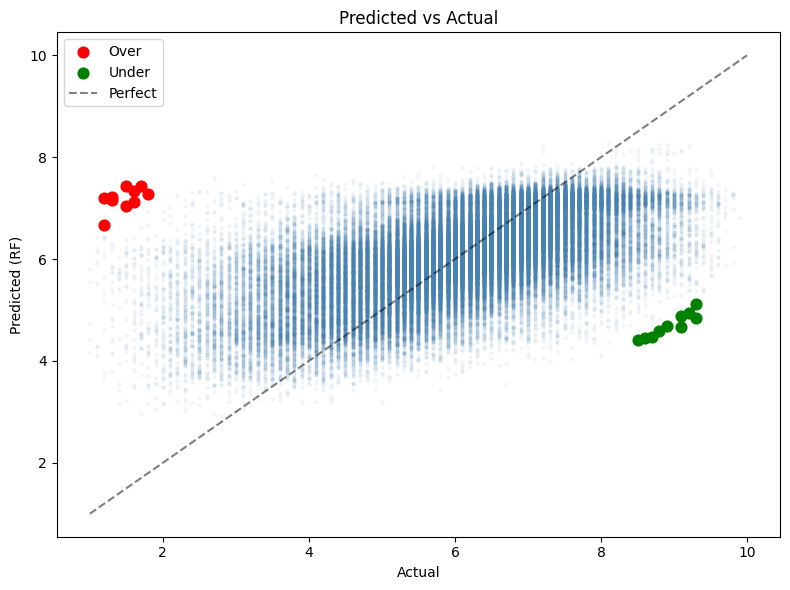

In [18]:
# ניתוח איכותי — Top 5 outliers
df_err['abs_rf'] = df_err['error_rf'].abs()
top5 = df_err.nlargest(5, 'abs_rf').merge(
    df_raw[['tconst','Country','runtimeMinutes','numVotes','plot']], on='tconst', how='left')

print('=' * 70)
for rank, row in enumerate(top5.itertuples(), 1):
    direction = 'OVER' if row.error_rf > 0 else 'UNDER'
    plot_text = str(row.plot)[:250]+'...' if pd.notna(row.plot) and len(str(row.plot))>250 else str(row.plot)
    print(f'#{rank} [{direction}] {row.primaryTitle} ({int(row.startYear) if pd.notna(row.startYear) else "?"})')
    print(f'  Genres: {row.genres} | Country: {row.Country if pd.notna(row.Country) else "Unknown"}')
    print(f'  Actual: {row.averageRating:.1f} → Pred: {row.pred_rf:.2f} (err: {row.error_rf:+.2f})')
    print(f'  Plot: {plot_text}')
    print()

# השוואה בין מודלים
over_rf  = set(df_err.nlargest(10,'error_rf')['primaryTitle'])
over_en  = set(df_err.nlargest(10,'error_en')['primaryTitle'])
under_rf = set(df_err.nsmallest(10,'error_rf')['primaryTitle'])
under_en = set(df_err.nsmallest(10,'error_en')['primaryTitle'])
print(f'Over overlap  (RF∩EN): {len(over_rf & over_en)}/10')
print(f'Under overlap (RF∩EN): {len(under_rf & under_en)}/10')

# Scatter
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y, y_pred_rf, alpha=0.05, s=5, color='steelblue')
over_idx  = df_err.nlargest(10,'error_rf').index
under_idx = df_err.nsmallest(10,'error_rf').index
ax.scatter(y[over_idx],  y_pred_rf[over_idx],  color='red',   s=60, label='Over',  zorder=5)
ax.scatter(y[under_idx], y_pred_rf[under_idx], color='green', s=60, label='Under', zorder=5)
ax.plot([1,10],[1,10],'k--',alpha=0.5,label='Perfect')
ax.set(xlabel='Actual', ylabel='Predicted (RF)', title='Predicted vs Actual')
ax.legend(); plt.tight_layout()
plt.savefig('error_scatter.png', dpi=100); plt.show()


##  13. Fairness Analysis

                 Slice     N   RMSE    MAE  %_above
               Overall 23112 1.0713 0.8093      0.0
    Genre: Documentary  2614 1.0065 0.7271     -6.0
         Genre: Horror  2002 1.1574 0.9127      8.0
         Genre: Action  2877 1.1525 0.8765      7.6
          Genre: Drama 11726 1.0004 0.7558     -6.6
      Genre: Biography   800 0.8896 0.6511    -17.0
       Genre: Thriller  2368 1.1050 0.8559      3.1
           Country: US  4206 0.9182 0.6852    -14.3
    Country: East_Asia   730 0.7964 0.6065    -25.7
        Country: Other 18176 1.1130 0.8462      3.9
         Decade: 1970s  1549 0.9755 0.7619     -8.9
         Decade: 1980s  1933 0.9718 0.7598     -9.3
         Decade: 1990s  2063 0.9832 0.7668     -8.2
         Decade: 2000s  3497 1.1046 0.8303      3.1
         Decade: 2010s  6719 1.1424 0.8577      6.6
         Decade: 2020s  3683 1.2172 0.9224     13.6
Data: Budget+BoxOffice  2400 0.9511 0.7161    -11.2
   Data: חסר לפחות אחד 20712 1.0843 0.8201      1.2


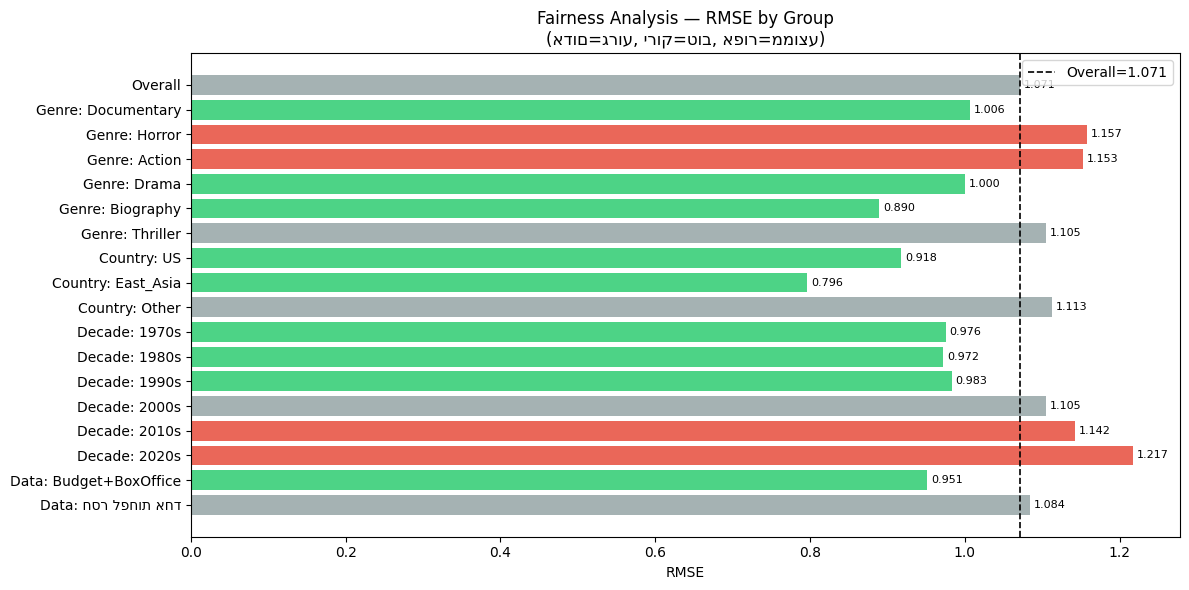

In [20]:
df_fair = df_test.copy()
X_fair  = prepare_data(df_fair)
for col in ALL_GENRES:
    df_fair[f'genre_{col}'] = X_fair[f'genre_{col}'].values
df_fair['country_group'] = X_fair['country_group'].values
df_fair['decade']  = (df_fair['startYear'].apply(
    lambda x: int(pd.to_numeric(x, errors='coerce')) if pd.notna(x) else 2000) // 10 * 10)
df_fair['y_pred']  = best_rf.predict(X_test)
df_fair['y_true']  = y_test

def slice_metrics(mask, label):
    sub = df_fair[mask]
    if len(sub) < 50: return None
    return {'Slice': label, 'N': len(sub),
            'RMSE': round(np.sqrt(mean_squared_error(sub['y_true'],sub['y_pred'])),4),
            'MAE':  round(mean_absolute_error(sub['y_true'],sub['y_pred']),4)}

rows = [slice_metrics(np.ones(len(df_fair),dtype=bool), 'Overall')]


for g in ['Documentary', 'Horror', 'Action', 'Drama', 'Biography', 'Thriller']:
    r = slice_metrics(df_fair[f'genre_{g}']==1, f'Genre: {g}'); 
    if r: rows.append(r)

for grp in ['US','East_Asia','Other']:
    r = slice_metrics(df_fair['country_group']==grp, f'Country: {grp}')
    if r: rows.append(r)

for dec in sorted(df_fair['decade'].unique()):
    if dec < 1970: continue
    r = slice_metrics(df_fair['decade']==dec, f'Decade: {dec}s')
    if r: rows.append(r)

has_full = df_fair['budget'].notna() & df_fair['BoxOffice'].notna()
rows.append(slice_metrics(has_full,    'Data: Budget+BoxOffice'))
rows.append(slice_metrics(~has_full,   'Data: חסר לפחות אחד'))

fairness_df = pd.DataFrame([r for r in rows if r])
overall = fairness_df.loc[fairness_df['Slice']=='Overall','RMSE'].values[0]
fairness_df['%_above'] = ((fairness_df['RMSE']/overall - 1)*100).round(1)
print(fairness_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
rmse_vals = fairness_df['RMSE'].tolist()
slices    = fairness_df['Slice'].tolist()
colors = ['#e74c3c' if r>overall*1.05 else '#2ecc71' if r<overall*0.95 else '#95a5a6' for r in rmse_vals]
bars = ax.barh(slices[::-1], rmse_vals[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(overall, color='black', ls='--', lw=1.2, label=f'Overall={overall:.3f}')
for bar, val in zip(bars, rmse_vals[::-1]):
    ax.text(val+0.005, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)
ax.set_xlabel('RMSE')
ax.set_title('Fairness Analysis — RMSE by Group\n(אדום=גרוע, ירוק=טוב, אפור=ממוצע)')
ax.legend(); plt.tight_layout()
plt.savefig('fairness_analysis.png', dpi=100); plt.show()


##  14. שמירת המודל

In [21]:
best_model      = best_rf if rf_test <= en_test else best_en
best_model_name = 'Random Forest' if rf_test <= en_test else 'Elastic Net'
print(f'Best model: {best_model_name}')
print(f'EN  → CV={en_rmse:.4f} Test={en_test:.4f} Adj.R²={en_adj:.4f}')
print(f'RF  → CV={rf_rmse:.4f} Test={rf_test:.4f} Adj.R²={rf_adj:.4f}')

# Re-fit על כל הנתונים
X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all = np.concatenate([y_train, y_test])
best_model.fit(X_all, y_all)

# Final metrics
final_r2  = r2_score(y_test, best_rf.predict(X_test))
final_adj = adjusted_r2(final_r2, len(y_test), N_FEATURES)
print(f'\nTest RMSE={rf_test:.4f} | MAE={mean_absolute_error(y_test,best_rf.predict(X_test)):.4f} | Adj.R²={final_adj:.4f}')

joblib.dump(best_model, 'model.pkl')
joblib.dump({'actor_quality_map': ACTOR_QUALITY_MAP,
             'global_mean_rating': GLOBAL_MEAN_RATING}, 'actor_quality.pkl')
print('Saved: model.pkl | actor_quality.pkl')

loaded = joblib.load('model.pkl')
preds  = loaded.predict(X_test.iloc[:3])
for i,(p,a) in enumerate(zip(preds, y_test[:3])):
    print(f'  Sample {i+1}: pred={p:.2f} actual={a:.2f}')


Best model: Elastic Net
EN  → CV=1.0650 Test=1.0680 Adj.R²=0.3227
RF  → CV=1.0249 Test=1.0713 Adj.R²=0.3727

Test RMSE=1.0713 | MAE=0.8093 | Adj.R²=0.3064
Saved: model.pkl | actor_quality.pkl
  Sample 1: pred=5.95 actual=5.10
  Sample 2: pred=6.01 actual=3.50
  Sample 3: pred=6.85 actual=7.20


##  15. סיכום

### מסלול השיפורים

| גרסה | שינוי | RMSE (RF) | R² (RF) |
|:----:|-------|:---------:|:-------:|
| v1 | genres שבורים, 8 ז'אנרים | 1.192 | 0.212 |
| v2 | תיקון genres + 20 ז'אנרים | 1.099 | 0.278 |
| v3 | actor_quality LOO | ~1.048 | ~0.344 |
| **v4** | KNNImputer + RobustScaler + OHE + RepeatedKFold | ← תוצאות | ← תוצאות |


